<a href="https://colab.research.google.com/github/Z0RR001/ICNPG2026_ejercicio1/blob/main/ICNPG2026_ejercicio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: Simulación de Difusión 1D



```
# Esto tiene formato de código
```

La temperatura $u$ de una barra unidimensional de longitud $L$ descrita por la **ecuación de difusión**:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

Utilizando un esquema de diferencias finitas hacia adelante en el tiempo y centradas en el espacio (**Euler explícito**), la actualización de la temperatura $u$ en la posición $i$ para el tiempo $n+1$ se puede discretizar como:

$$u_i^{n+1} = u_i^n + r(u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$

donde $r = \alpha \frac{\Delta t}{\Delta x^2}$ es el parámetro de control. Para que el método sea numéricamente estable, se debe cumplir la condición de Courant: $r \leq 0.5$.

1. Completar el template provisto del programa en **CUDA C** que evolucione un **pulso cuadrado** de temperatura en el centro de la barra y registre la evolución del punto central $u(L/2)$ a lo largo del tiempo, que cumple las siguientes condiciones,

  * **Condición Inicial:** Definir un perfil donde $u = 1.0$ en la región central (por ejemplo, $L/4 < i < 3L/4$) y $u = 0.0$ en el resto de la barra.
  * **Condiciones de Contorno:** Aplicar condiciones de **Dirichlet absorbentes**, manteniendo los extremos fijos: $u_0 = u_{L-1} = 0$.
  * **Gestión de Memoria (Double Buffering):**
    * Utilizar dos arreglos en la GPU (`d_u_old` y `d_u_new`) para evitar la lectura de valores que ya han sido modificados por otros hilos en el mismo paso temporal (*race condition*).
    * Realizar el intercambio (*swap*) de punteros en el Host (CPU) al finalizar cada iteración del bucle temporal.
  * **Optimización de Transferencia (Bus PCIe):**
    * **Crucial:** No copiar el vector completo de vuelta al Host en cada paso de tiempo.
    * Dado que solo nos interesa la evolución del centro, realizar una transferencia selectiva de **un único valor** `float` desde la dirección de memoria `&d_u_old[L/2]` hacia una variable local en el Host mediante `cudaMemcpy`.

2. Graficar el valor central de la temperatura de la barra en función del tiempo.

3. Graficar el tiempo de ejecución vs $L=1024, 2048, \dots, 4194304$.

4. *Opcional*: hacer una pelicula con todo el perfil $T(x,t)$ vs $t$.

Clonar github

In [1]:
%%bash

git clone https://github.com/Z0RR001/ICNPG2026_ejercicio1.git

Cloning into 'ICNPG2026_ejercicio1'...


# Template a completar y probar

In [2]:
%%writefile difusion_1d.cu
#include <iostream>
#include <fstream>
#include <vector>
#include <cstdio>
#include <cuda_runtime.h>
#include "gpu_timer.h"

// Kernel que implementa el stencil de diferencias finitas 1D
__global__ void diffusionKernel(float *u_old, float *u_new, float r, int L)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i > 0 && i < L-1)
    {
        u_new[i] = u_old[i] + r*(u_old[i+1] - 2*u_old[i] + u_old[i-1]);
    }
}

int main() {
    // 1. Configuración de parámetros
    const int L = 512;            // Puntos en la barra
    const int steps = 20000;      // Pasos temporales
    const int output_freq = 100;  // Frecuencia de muestreo del centro
    const float r = 0.4f;         // Coeficiente de estabilidad (r <= 0.5)

    size_t size = L * sizeof(float);

    // 2. Inicialización del perfil (Pulso Cuadrado)
    std::vector<float> h_u(L, 0.0f);
   // for (int i = L / 4; i < 3 * L / 4; ++i) {
   //     h_u[i] = 1.0f;
   // }

    for(int i=0;i<L;i++)
    {

      if(i > L/4 && i < 3*L/4)
          h_u[i] = 1.0;
      else
          h_u[i] = 0.0;
    }

    // 3. Reserva de memoria en GPU y Double Buffering
    float *d_u_old, *d_u_new;
    cudaMalloc(&d_u_old, size);
    cudaMalloc(&d_u_new, size);

    // Copiar condición inicial y limpiar el segundo buffer
    cudaMemcpy(d_u_old, h_u.data(), size, cudaMemcpyHostToDevice);
    cudaMemset(d_u_new, 0, size);

    // 4. Parámetros de ejecución de CUDA
    int threadsPerBlock = 256;
    int blocksPerGrid = (L + threadsPerBlock - 1) / threadsPerBlock;


    std::ofstream archivo("log.txt");
    std::printf("# Paso \t Temperatura_Centro\n");
     archivo << "Tiempo_(ms) \t Temperatura_Centro" << "\n";


    // Agregar timers de GPU para medir el tiempo de ejecución de todo el loop
    gpu_timer Reloj;
	  Reloj.tic();

    // 5. Bucle de evolución temporal
    for (int s = 0; s <= steps; ++s) {

        // --- OPTIMIZACIÓN DE TRANSFERENCIA ---
        // Extraemos solo el punto central del buffer actual antes del swap
        if (s % output_freq == 0 && s != 0) {                                        //agregue "&& s != 0" porque sino me imprimía  el primer valor de  temperatura = 0
            // Se transfiere un único float (4 bytes) evitando copiar todo el array
            float center;
            cudaMemcpy(&center, &d_u_new[L/2], sizeof(float), cudaMemcpyDeviceToHost);

            // Se imprime ese único float en el host
            printf("%d \t %f\n", s/output_freq, center);
            archivo << Reloj.tac() << "\t \t \t \t \t" << center << "\n";
        }

        // Lanzamiento del kernel
        diffusionKernel<<<blocksPerGrid, threadsPerBlock>>>(d_u_old, d_u_new, r, L);

        // --- GESTIÓN DE MEMORIA (Swap de punteros) ---
        // Intercambiamos los buffers: el "nuevo" pasa a ser el "viejo" para el siguiente paso
        float *temp = d_u_old;
        d_u_old = d_u_new;
        d_u_new = temp;
    }

    // Imprimir el tiempo de ejecución de todo el loop
    printf("\nTiempo de ejecución del loop= %lf ms\n", Reloj.tac());

    // 6. Liberación de memoria
    cudaFree(d_u_old);
    cudaFree(d_u_new);

    // 7. Cierre del archivo de salida
    archivo.close();

    return 0;
}

Writing difusion_1d.cu


Si lo completo bien, esto deberia compilar y correr el programa, el cual deberia imprimir los valores en el centro cada 100 pasos.

In [3]:
!nvcc -arch=sm_75 difusion_1d.cu -o difusion_1d
!./difusion_1d

# Paso 	 Temperatura_Centro
1 	 1.000000
2 	 1.000000
3 	 1.000000
4 	 1.000000
5 	 1.000000
6 	 1.000000
7 	 1.000000
8 	 1.000000
9 	 1.000000
10 	 0.999995
11 	 0.999984
12 	 0.999962
13 	 0.999924
14 	 0.999863
15 	 0.999770
16 	 0.999638
17 	 0.999459
18 	 0.999226
19 	 0.998932
20 	 0.998572
21 	 0.998142
22 	 0.997638
23 	 0.997056
24 	 0.996395
25 	 0.995655
26 	 0.994834
27 	 0.993934
28 	 0.992955
29 	 0.991898
30 	 0.990766
31 	 0.989559
32 	 0.988282
33 	 0.986936
34 	 0.985523
35 	 0.984048
36 	 0.982511
37 	 0.980918
38 	 0.979269
39 	 0.977569
40 	 0.975820
41 	 0.974025
42 	 0.972186
43 	 0.970307
44 	 0.968390
45 	 0.966436
46 	 0.964450
47 	 0.962433
48 	 0.960387
49 	 0.958315
50 	 0.956218
51 	 0.954099
52 	 0.951959
53 	 0.949800
54 	 0.947625
55 	 0.945434
56 	 0.943229
57 	 0.941011
58 	 0.938783
59 	 0.936545
60 	 0.934298
61 	 0.932045
62 	 0.929785
63 	 0.927520
64 	 0.925251
65 	 0.922978
66 	 0.920703
67 	 0.918426
68 	 0.916149
69 	 0.913873
70 	 0.911599
7

Gráfico hecho con Gemini

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the log file, skipping the first line (header from printf, not the csv header)
# The actual header with column names is the first line of the file itself.
# The delimiter is a tab ('\t') and there are multiple spaces after the time column.
# Use regex to handle variable spaces as delimiter.
df = pd.read_csv('log.txt', sep='\s+', header=0, engine='python')

# Strip any whitespace from column names and content
df.columns = df.columns.str.strip()
# No es necesario aplicar strip al contenido si ya es numérico o si se maneja en la conversión.

# Convert columns to numeric, coercing errors to NaN
df['Tiempo_(ms)'] = pd.to_numeric(df['Tiempo_(ms)'], errors='coerce')
df['Temperatura_Centro'] = pd.to_numeric(df['Temperatura_Centro'], errors='coerce')

# Drop rows with NaN values that resulted from coercion
df.dropna(inplace=True)

# Display the first few rows of the DataFrame to verify
display(df.head())


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11457/1453090476.py:8: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('log.txt', sep='\s+', header=0, engine='python')


,Tiempo_(ms),Temperatura_Centro
0,0.45056,1.0
1,0.88880,1.0
2,1.27210,1.0
3,1.63837,1.0
4,2.04950,1.0


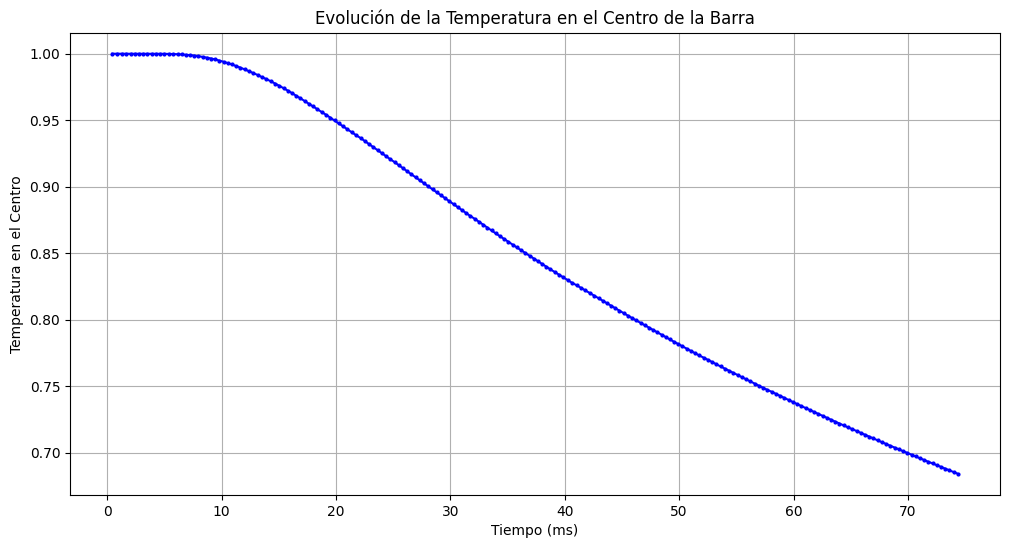

In [ ]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df['Tiempo_(ms)'], df['Temperatura_Centro'], marker='o', markersize=2, linestyle='-', color='blue')
plt.title('Evolución de la Temperatura en el Centro de la Barra')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Temperatura en el Centro')
plt.grid(True)
plt.show()
